In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport
import numpy as np

In [10]:
file = "/home/eder/projects/temporal-series/data/MetroPT3(AirCompressor).csv"
df = pd.read_csv(file)

In [11]:
df.head()

,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


/tmp/ipykernel_5814/3980149307.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels (), rotation=45)


[Text(-1000.0, 0, '−1000'),
 Text(0.0, 0, '0'),
 Text(1000.0, 0, '1000'),
 Text(2000.0, 0, '2000'),
 Text(3000.0, 0, '3000'),
 Text(4000.0, 0, '4000'),
 Text(5000.0, 0, '5000'),
 Text(6000.0, 0, '6000')]

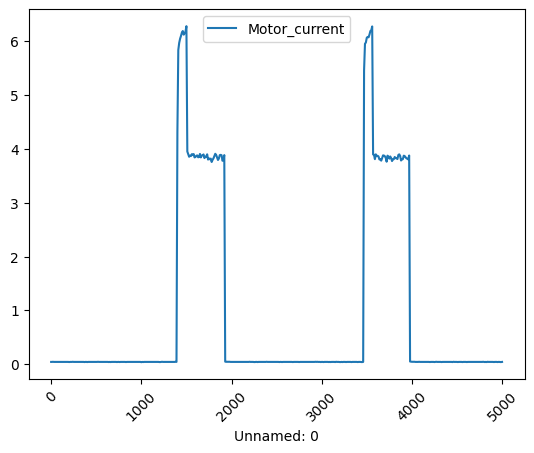

In [12]:
ax = df.loc[: 500] .plot (x='Unnamed: 0',y='Motor_current')
ax.set_xticklabels(ax.get_xticklabels (), rotation=45)

In [15]:
df.shape

(1516948, 17)

In [14]:
np.random.random (df.shape).shape

(1516948, 17)

In [16]:
df.isna().sum()

Unnamed: 0         0
timestamp          0
TP2                0
TP3                0
H1                 0
DV_pressure        0
Reservoirs         0
Oil_temperature    0
Motor_current      0
COMP               0
DV_eletric         0
Towers             0
MPG                0
LPS                0
Pressure_switch    0
Oil_level          0
Caudal_impulses    0
dtype: int64

In [26]:
mv_dataset = df.mask(np.random.random (df.shape) < .02, other=pd.NA)

#Step 1.5: Plot the variable with missing values
#Step 2: Rolling mean imputation

mv_dataset ['Oil_temperature' ] .fillna (mv_dataset ['Oil_temperature'] . rolling (window=100) .mean () )

0          53.600
1          53.675
2          53.600
3          53.425
4          53.475
            ...  
1516943    59.675
1516944    59.600
1516945    59.600
1516946    59.550
1516947    59.475
Name: Oil_temperature, Length: 1516948, dtype: float64

In [27]:
mv_dataset.isna().sum()

Unnamed: 0         30397
timestamp          30142
TP2                30447
TP3                30257
H1                 30349
DV_pressure        30079
Reservoirs         30199
Oil_temperature    30442
Motor_current      30416
COMP               30414
DV_eletric         30312
Towers             30776
MPG                30516
LPS                30337
Pressure_switch    30428
Oil_level          30220
Caudal_impulses    30267
dtype: int64

/tmp/ipykernel_5814/2173953648.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels (), rotation=45)


[Text(-20000.0, 0, '−20000'),
 Text(0.0, 0, '0'),
 Text(20000.0, 0, '20000'),
 Text(40000.0, 0, '40000'),
 Text(60000.0, 0, '60000'),
 Text(80000.0, 0, '80000'),
 Text(100000.0, 0, '100000'),
 Text(120000.0, 0, '120000')]

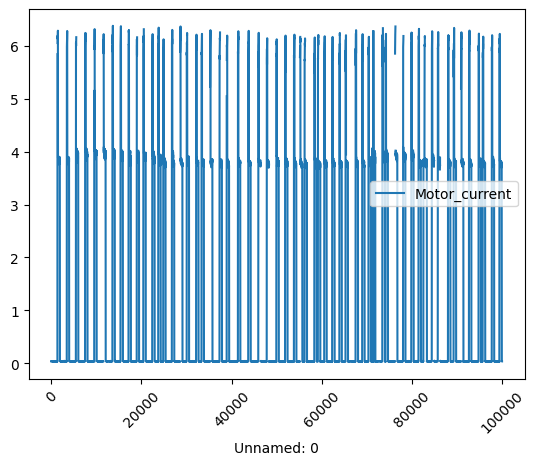

In [28]:
ax = mv_dataset.iloc[:10000].plot (x='Unnamed: 0',y='Motor_current')
ax.set_xticklabels(ax.get_xticklabels (), rotation=45)

/tmp/ipykernel_5814/1583826200.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels (), rotation=45)


[Text(-2000.0, 0, '−2000'),
 Text(0.0, 0, '0'),
 Text(2000.0, 0, '2000'),
 Text(4000.0, 0, '4000'),
 Text(6000.0, 0, '6000'),
 Text(8000.0, 0, '8000'),
 Text(10000.0, 0, '10000'),
 Text(12000.0, 0, '12000')]

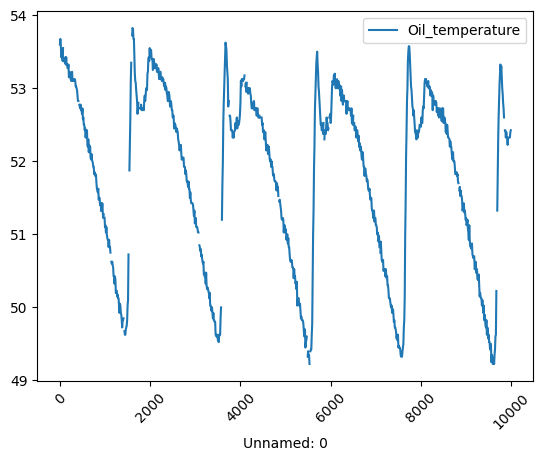

In [32]:
ax = mv_dataset.iloc[:1000].plot (x='Unnamed: 0',y='Oil_temperature')
ax.set_xticklabels(ax.get_xticklabels (), rotation=45)

In [33]:
from statsmodels.tsa.stattools import adfuller
result = adfuller (df['Oil_temperature' ] . loc [ : 1000])

In [34]:
result

(np.float64(-3.897852449261933),
 np.float64(0.0020507088662965792),
 14,
 986,
 {'1%': np.float64(-3.4369994990319355),
  '5%': np.float64(-2.8644757356011743),
  '10%': np.float64(-2.5683331327427803)},
 np.float64(-1766.5605922799168))